# Exportation des graphiques

In [1]:
from os import getenv
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from dataviz_tips.data import load_tips
from dataviz_tips.plots import (
    plot_boxplot_mpl,
    plot_boxplot_sns,
    plot_correlation_heatmap_mpl,
    plot_correlation_heatmap_sns,
    plot_histogram_mpl,
    plot_histogram_sns,
    plot_scatter_mpl,
    plot_scatter_sns,
    plot_size_counts_mpl,
    plot_size_counts_sns,
    save_figure,
)
from dataviz_tips.stats import correlation_matrix

## Configuration

Le dossier de sortie, le nombre de classes (`BINS`) et la liste des 14 figures sont définis une seule fois. `BINS` est identique pour les deux bibliothèques.

In [2]:
tips = load_tips()
corr = correlation_matrix(tips)

# Dossier de sortie : variable d'environnement PATH_FIGURE, sinon ../reports/figures
# (chemin relatif au dossier notebooks/).
FIGURES_DIR = Path(getenv("PATH_FIGURE", "../reports/figures"))

# Même nombre de classes pour Matplotlib et Seaborn : comparaison équitable.
BINS = 20

# (nom du fichier, fonction de tracé, données, colonnes, options)
FIGURES = [
    # Matplotlib figures
    (
        "histogram_total_bill_mpl",
        plot_histogram_mpl,
        tips,
        ("total_bill",),
        {"bins": BINS},
    ),
    ("histogram_tip_mpl", plot_histogram_mpl, tips, ("tip",), {"bins": BINS}),
    ("boxplot_total_bill_mpl", plot_boxplot_mpl, tips, ("total_bill",), {}),
    ("boxplot_tip_mpl", plot_boxplot_mpl, tips, ("tip",), {}),
    (
        "scatter_total_bill_vs_tip_mpl",
        plot_scatter_mpl,
        tips,
        ("total_bill", "tip"),
        {},
    ),
    ("size_counts_mpl", plot_size_counts_mpl, tips, ("size",), {}),
    ("heatmap_mpl", plot_correlation_heatmap_mpl, corr, (), {}),
    # Seaborn figures
    (
        "histogram_total_bill_sns",
        plot_histogram_sns,
        tips,
        ("total_bill",),
        {"bins": BINS},
    ),
    ("histogram_tip_sns", plot_histogram_sns, tips, ("tip",), {"bins": BINS}),
    ("boxplot_total_bill_sns", plot_boxplot_sns, tips, ("total_bill",), {}),
    ("boxplot_tip_sns", plot_boxplot_sns, tips, ("tip",), {}),
    (
        "scatter_total_bill_vs_tip_sns",
        plot_scatter_sns,
        tips,
        ("total_bill", "tip"),
        {},
    ),
    ("size_counts_sns", plot_size_counts_sns, tips, ("size",), {}),
    ("heatmap_sns", plot_correlation_heatmap_sns, corr, (), {}),
]

## Export

Une seule boucle trace, enregistre puis ferme chaque figure. Le même style est appliqué à Matplotlib et à Seaborn.

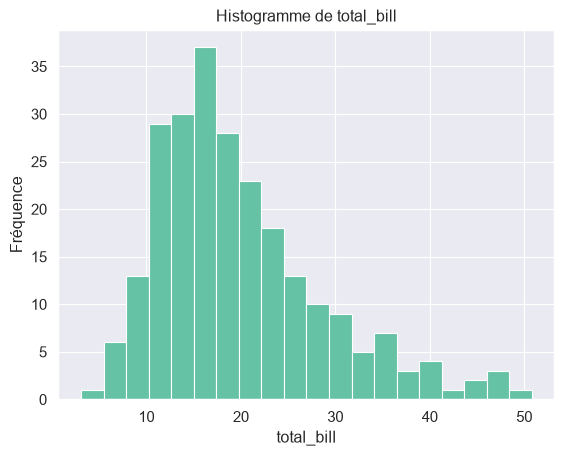

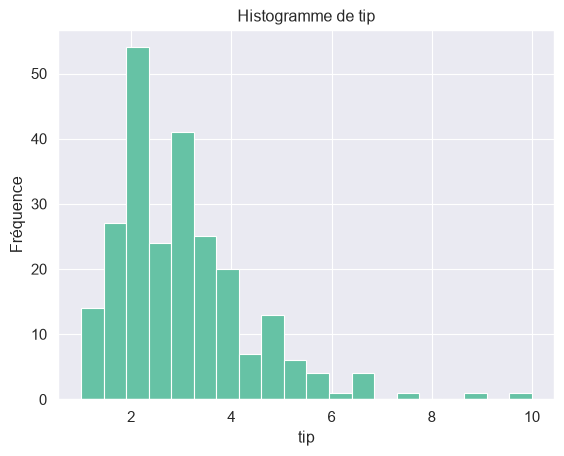

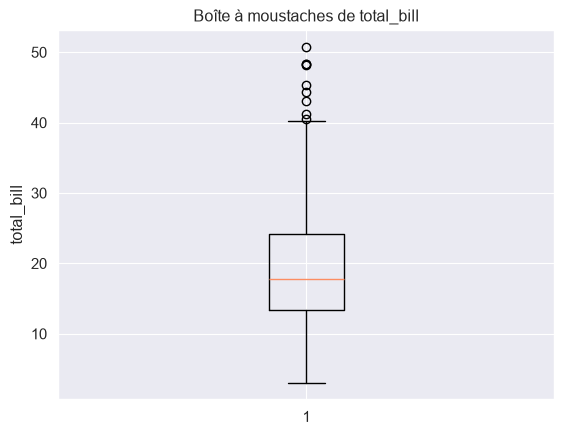

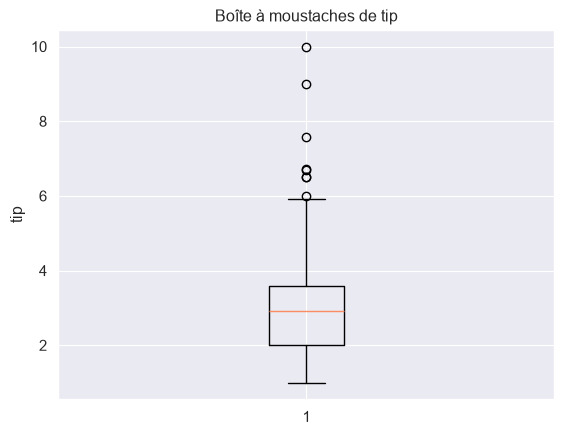

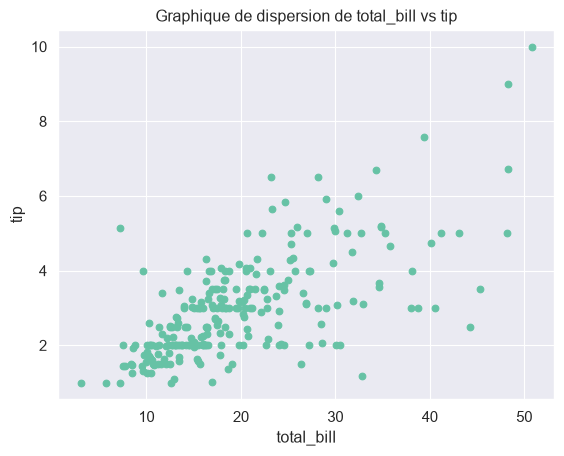

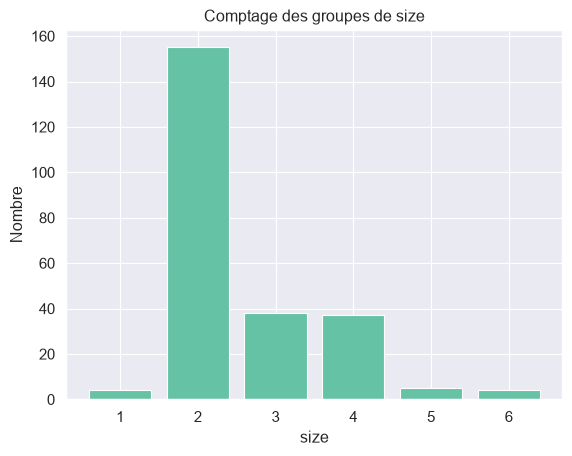

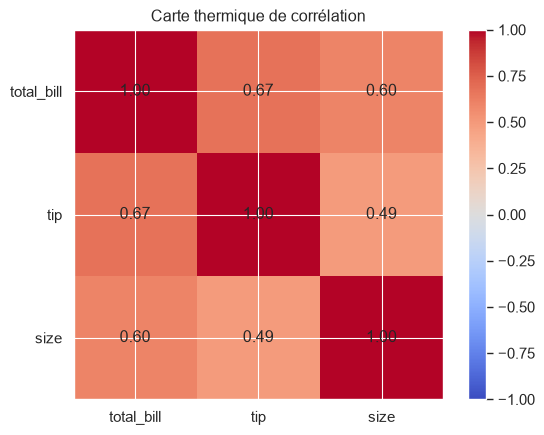

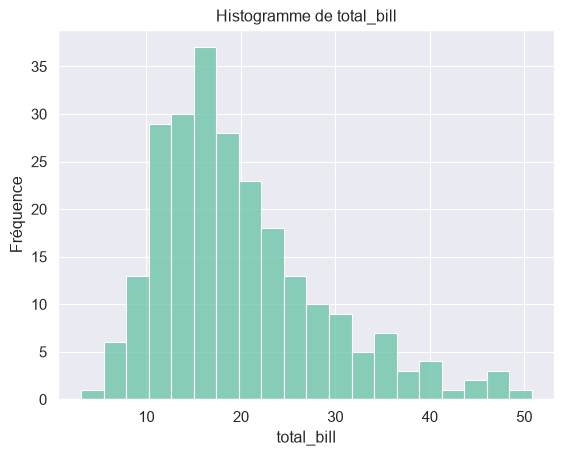

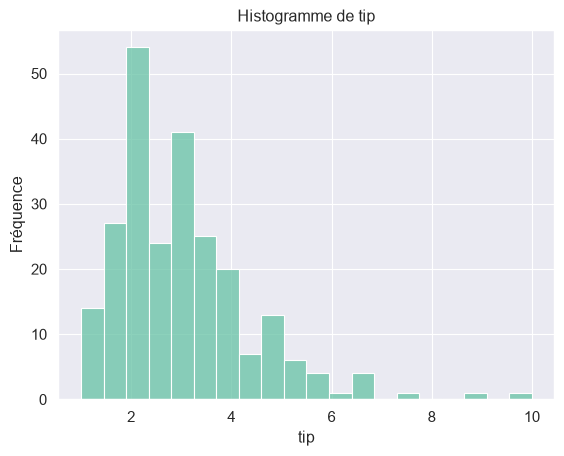

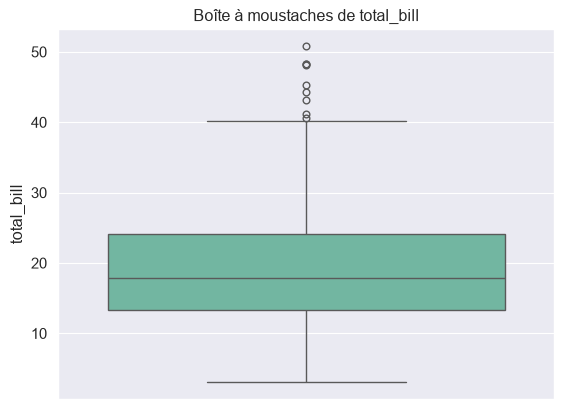

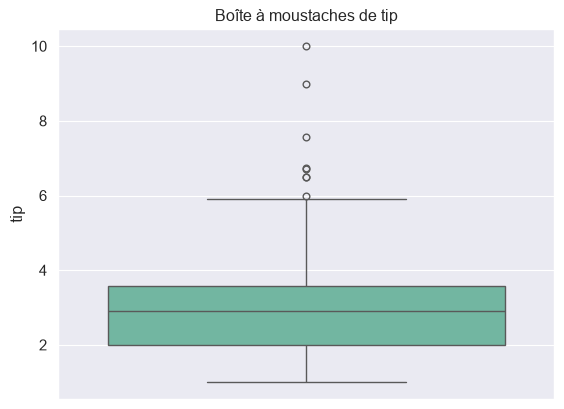

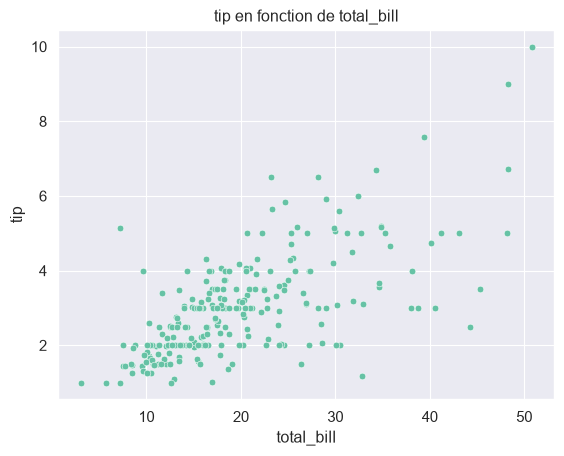

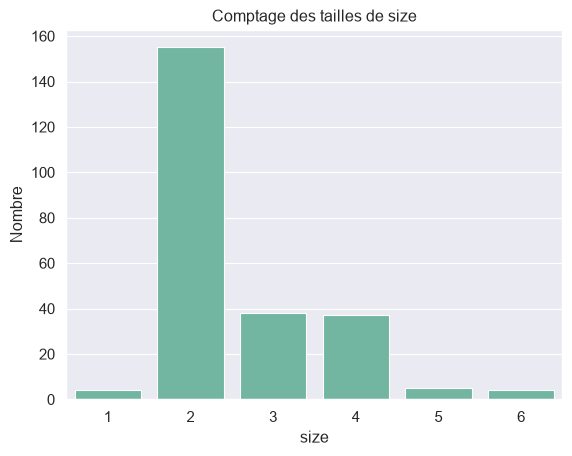

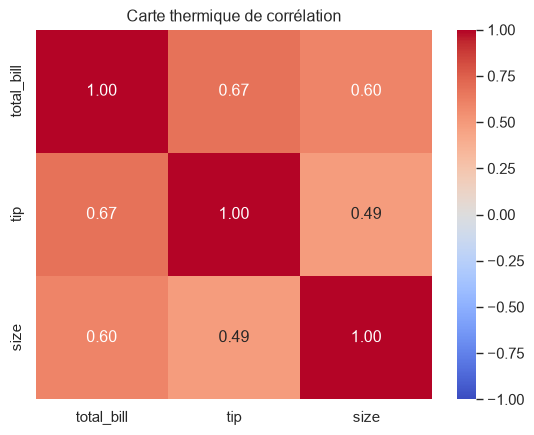

In [3]:
with (
    sns.axes_style("darkgrid"),
    sns.plotting_context("paper", font_scale=1.2),
    sns.color_palette("Set2"),
):
    for name, func, df, columns, options in FIGURES:
        fig, ax = plt.subplots()
        func(df, *columns, ax=ax, **options)
        save_figure(fig, FIGURES_DIR / f"{name}.png")
        plt.show()
        plt.close(fig)

## Vérification

Les 14 fichiers doivent être présents dans le dossier de sortie.

In [4]:
sorted(path.name for path in FIGURES_DIR.glob("*.png"))

['boxplot_tip_mpl.png',
 'boxplot_tip_sns.png',
 'boxplot_total_bill_mpl.png',
 'boxplot_total_bill_sns.png',
 'heatmap_mpl.png',
 'heatmap_sns.png',
 'histogram_tip_mpl.png',
 'histogram_tip_sns.png',
 'histogram_total_bill_mpl.png',
 'histogram_total_bill_sns.png',
 'scatter_total_bill_vs_tip_mpl.png',
 'scatter_total_bill_vs_tip_sns.png',
 'size_counts_mpl.png',
 'size_counts_sns.png']